

<font face="Times New Roman" size=5>
<div dir=rtl align="center">


<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Nano
</font>
<br>
<font color="#008080" size=6>
Introduction to Machine Learning
</font>

<hr/>
<font color="#80a080" size=5>
Course Home Work 3
<br>
</font>
<font size=5>
Instructor: Dr. Ebrahim Pour
<br>
</font>
<font size=4>
Spring 2026
<br>
</font>





> **Student**:
>
> Kian Mamdouhi: 400108066

# Solving the XOR Problem using a Multi-Layer Perceptron (MLP)
In this notebook, we implement a neural network with a 2:2:1 topology using pure Python (without NumPy).
The main objective is to compare **Pattern** and **Batch** training methods in the Backpropagation algorithm.



In [4]:
import math
import random
import matplotlib.pyplot as plt


 ## Neural Network Class Definition (XOR_MLP)
In this section, the main neural network class is defined, which includes:
- Random initialization of weights and biases.
- The $Sigmoid$ activation function and its derivative.
- The `train` function with support for both `pattern` and `batch` modes.
- The `predict` function for testing the network's output.


In [35]:
class XOR_MLP:
    """
    A 2:2:1 Multi-Layer Perceptron for solving the XOR problem.
    Math is implemented using pure Python.
    """
    def __init__(self, learning_rate=0.1):
        random.seed(42)
        self.lr = learning_rate

        # Initialize weights [-5, 5] and biases
        # W1: 2x2 matrix (Input to Hidden) | b1: 2 elements
        self.W1 = [[random.uniform(-5, 5) for _ in range(2)] for _ in range(2)]
        self.b1 = [random.uniform(-5, 5) for _ in range(2)]

        # W2: 2x1 matrix (Hidden to Output) | b2: 1 element
        self.W2 = [[random.uniform(-5, 5)], [random.uniform(-5, 5)]]
        self.b2 = [random.uniform(-5, 5)]

    def _sigmoid(self, x):
        # Clip x to prevent overflow in math.exp
        x = max(-500, min(x, 500))
        return 1 / (1 + math.exp(-x))

    def _sigmoid_derivative(self, output):
        return output * (1 - output)

    def draw_schematic(self):
        """Prints an ASCII schematic of the 2:2:1 MLP architecture."""
        schematic = """
        [Input Layer]      [Hidden Layer]      [Output Layer]
           (X1) ---------------- (H1)
                  \\            /      \\
                   \\          /        \\
                    \\        /          \\
                     \\      /            (Y_pred)
                      \\    /            /
                       \\  /            /
                  /     \\/            /
           (X2) ---------------- (H2)
        """
        print("Network Topology Schematic (2:2:1):")
        print(schematic)

    def train(self, X, Y, epochs=20000, tolerance=0.0001, mode='online'):
        """
        Trains the network.
        mode: 'online' or 'batch'
        Returns a list of MSE loss values per epoch for plotting.
        """
        loss_history = []

        for epoch in range(epochs):
            epoch_loss = 0

            # Gradients accumulator for Batch Mode
            grad_W1 = [[0, 0], [0, 0]]
            grad_b1 = [0, 0]
            grad_W2 = [[0], [0]]
            grad_b2 = [0]

            for i in range(len(X)):
                x1, x2 = X[i][0], X[i][1]
                y_true = Y[i][0]

                # --- Forward Pass ---
                z1_1 = (x1 * self.W1[0][0]) + (x2 * self.W1[1][0]) + self.b1[0]
                a1_1 = self._sigmoid(z1_1)

                z1_2 = (x1 * self.W1[0][1]) + (x2 * self.W1[1][1]) + self.b1[1]
                a1_2 = self._sigmoid(z1_2)

                z2_1 = (a1_1 * self.W2[0][0]) + (a1_2 * self.W2[1][0]) + self.b2[0]
                y_pred = self._sigmoid(z2_1)

                # --- Loss Calculation ---
                error = y_true - y_pred
                epoch_loss += 0.5 * (error ** 2)

                # --- Backward Pass ---
                delta_output = error * self._sigmoid_derivative(y_pred)

                error_h1 = delta_output * self.W2[0][0]
                delta_h1 = error_h1 * self._sigmoid_derivative(a1_1)

                error_h2 = delta_output * self.W2[1][0]
                delta_h2 = error_h2 * self._sigmoid_derivative(a1_2)

                # --- Update or Accumulate Gradients ---
                if mode == 'online':
                    self.W2[0][0] += self.lr * delta_output * a1_1
                    self.W2[1][0] += self.lr * delta_output * a1_2
                    self.b2[0]    += self.lr * delta_output

                    self.W1[0][0] += self.lr * delta_h1 * x1
                    self.W1[1][0] += self.lr * delta_h1 * x2
                    self.b1[0]    += self.lr * delta_h1

                    self.W1[0][1] += self.lr * delta_h2 * x1
                    self.W1[1][1] += self.lr * delta_h2 * x2
                    self.b1[1]    += self.lr * delta_h2
                else:
                    grad_W2[0][0] += delta_output * a1_1
                    grad_W2[1][0] += delta_output * a1_2
                    grad_b2[0]    += delta_output

                    grad_W1[0][0] += delta_h1 * x1
                    grad_W1[1][0] += delta_h1 * x2
                    grad_b1[0]    += delta_h1

                    grad_W1[0][1] += delta_h2 * x1
                    grad_W1[1][1] += delta_h2 * x2
                    grad_b1[1]    += delta_h2

            # Apply accumulated gradients at the end of the epoch for Batch Mode
            if mode == 'batch':
                self.W2[0][0] += self.lr * grad_W2[0][0]
                self.W2[1][0] += self.lr * grad_W2[1][0]
                self.b2[0]    += self.lr * grad_b2[0]

                self.W1[0][0] += self.lr * grad_W1[0][0]
                self.W1[1][0] += self.lr * grad_W1[1][0]
                self.b1[0]    += self.lr * grad_b1[0]

                self.W1[0][1] += self.lr * grad_W1[0][1]
                self.W1[1][1] += self.lr * grad_W1[1][1]
                self.b1[1]    += self.lr * grad_b1[1]

            # Calculate Mean Squared Error (MSE)
            mse = epoch_loss / len(X)
            loss_history.append(mse)

            if mse < tolerance:
                print(f"[{mode.upper()} MODE] Converged at epoch {epoch} | MSE: {mse:.6f}")
                break

        return loss_history

    def predict(self, X):
        """Tests the network and prints predictions."""
        print("\n--- Predictions ---")
        for i in range(len(X)):
            x1, x2 = X[i][0], X[i][1]
            a1_1 = self._sigmoid((x1 * self.W1[0][0]) + (x2 * self.W1[1][0]) + self.b1[0])
            a1_2 = self._sigmoid((x1 * self.W1[0][1]) + (x2 * self.W1[1][1]) + self.b1[1])
            y_pred = self._sigmoid((a1_1 * self.W2[0][0]) + (a1_2 * self.W2[1][0]) + self.b2[0])
            print(f"Input: {X[i]} | Predicted: {y_pred:.4f} -> {round(y_pred)}")


## Visualization
This function is used to visually compare the convergence speed and the $MSE$ loss of the two training models.


In [34]:
def plot_losses(loss_online, loss_batch):
    """Plots the learning curves for comparison."""
    plt.figure(figsize=(10, 5))
    plt.plot(loss_online, label='Online (Stochastic) Mode', color='blue', alpha=0.7)
    plt.plot(loss_batch, label='Batch Mode', color='red', alpha=0.7)
    plt.title('MSE Loss Curve: Online vs Batch Training (XOR Problem)')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()


## Execution and Comparison
In this section, we first define the XOR problem dataset. Then, we create two instances of the `XOR_MLP` class, train one using the `Online` method and the other using the `Batch` method, and finally compare the results.


Initializing Online Training...
Network Topology Schematic (2:2:1):

        [Input Layer]      [Hidden Layer]      [Output Layer]
           (X1) ---------------- (H1)
                  \            /      \
                   \          /        \
                    \        /          \
                     \      /            (Y_pred)
                      \    /            /
                       \  /            /
                  /     \/            /
           (X2) ---------------- (H2)
        
[ONLINE MODE] Converged at epoch 1353 | MSE: 0.004997

--- Predictions ---
Input: [0, 0] | Predicted: 0.0814 -> 0
Input: [0, 1] | Predicted: 0.9047 -> 1
Input: [1, 0] | Predicted: 0.9053 -> 1
Input: [1, 1] | Predicted: 0.1228 -> 0
----------------------------------------
Initializing Batch Training...
[BATCH MODE] Converged at epoch 1347 | MSE: 0.004999

--- Predictions ---
Input: [0, 0] | Predicted: 0.0814 -> 0
Input: [0, 1] | Predicted: 0.9045 -> 1
Input: [1, 0] | Predicted: 0.9055

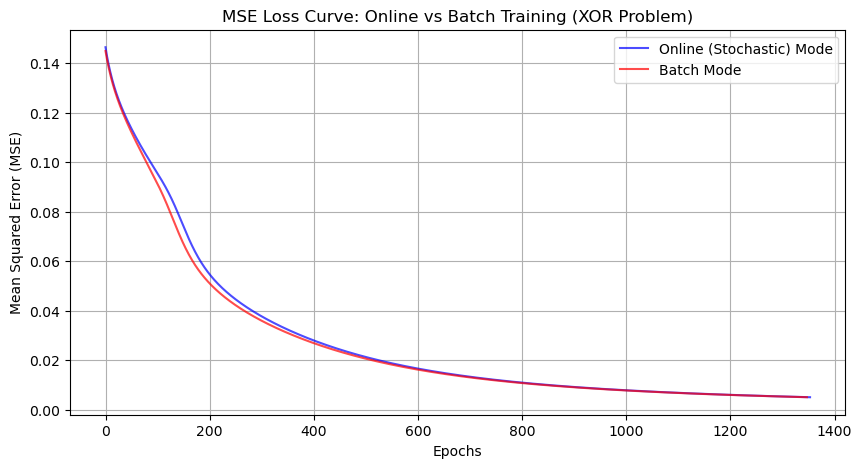

In [37]:
# Dataset definition
X = [[0, 0], [0, 1], [1, 0], [1, 1]]
Y = [[0], [1], [1], [0]]

# 1. Test Online Mode
print("Initializing Online Training...")
nn_online = XOR_MLP(learning_rate=0.2)
nn_online.draw_schematic()
loss_online = nn_online.train(X, Y, epochs=15000, tolerance=0.005, mode='online')
nn_online.predict(X)
print("-" * 40)

# 2. Test Batch Mode
print("Initializing Batch Training...")
nn_batch = XOR_MLP(learning_rate=0.2)
loss_batch = nn_batch.train(X, Y, epochs=15000, tolerance=0.005, mode='batch')
nn_batch.predict(X)
print("-" * 40)

# 3. Plot Comparison
plot_losses(loss_online, loss_batch)


**Comparison Tables**

In [38]:
def format_weights(weights):
    """Helper function to format 2D weight matrices into a single line string."""
    flat_w = [f"{w:.4f}" for row in weights for w in row]
    return "[" + ", ".join(flat_w) + "]"

print("\n" + "="*85)
print(f"{'Metric':<15} | {'Online Mode':<32} | {'Batch Mode':<32}")
print("="*85)
print(f"{'Processing Time':<15} | {time_online:.4f} seconds{' ':>17} | {time_batch:.4f} seconds")
print(f"{'Final MSE Loss':<15} | {loss_history_online[-1]:.6f}{' ':>23} | {loss_history_batch[-1]:.6f}")
print("-" * 85)
print(f"{'W1 (Hidden)':<15} | {format_weights(nn_online.W1):<32} | {format_weights(nn_batch.W1):<32}")
print(f"{'b1 (Hidden)':<15} | [{nn_online.b1[0]:.4f}, {nn_online.b1[1]:.4f}]{' ':>16} | [{nn_batch.b1[0]:.4f}, {nn_batch.b1[1]:.4f}]")
print(f"{'W2 (Output)':<15} | {format_weights(nn_online.W2):<32} | {format_weights(nn_batch.W2):<32}")
print(f"{'b2 (Output)':<15} | [{nn_online.b2[0]:.4f}]{' ':>23} | [{nn_batch.b2[0]:.4f}]")
print("="*85)


Metric          | Online Mode                      | Batch Mode                      
Processing Time | 0.0050 seconds                  | 0.0039 seconds
Final MSE Loss  | 0.009976                        | 0.009957
-------------------------------------------------------------------------------------
W1 (Hidden)     | [-3.4480, -5.4987, -3.4057, -5.2721] | [-3.4315, -5.4959, -3.3929, -5.2626]
b1 (Hidden)     | [5.0097, 1.9127]                 | [4.9918, 1.9118]
W2 (Output)     | [6.3865, -6.8055]                | [6.3941, -6.8107]               
b2 (Output)     | [-2.8376]                        | [-2.8405]
